In [2]:
import pandas as pd
import numpy as np
import random
from typing import Set, Tuple, Dict, Any, List
from pathlib import Path
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import requests
import json
import omnipath
from omnipath.interactions import OmniPath
from omnipath.interactions import AllInteractions
plt.style.use("../rw_visualization.mplstyle")

/nfs/research/saezrodriguez/rain/envs/miniconda3/envs/llm_grn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. False edges (removed edges)

Workflow: 
1. I first identified the removed edges between each consecutive year by considering only SIGNOR_ID.
2. Since SIGNOR_IDs can change for the same edge (same ENTITYA, ENTITYB, EFFECT), I then checked whether any of the removed edges actually still existed in the following year's data with different SIGNOR_IDs.
3. I removed those "reassigned" edges from the removed edges list.
4. I then further filtered the removed edges to keep only those edges whose nodes still exist in the latest 2025 data.
5. Finally, I checked again whether any of the removed edges had been added back in the 2025 data.

NOTE:
1. There are plenty of ribosomal subunit related edges being removed in 2021-2022 data.
2. There are only one removed edge being added back in 2025 data: {'old_signor_id': 'SIGNOR-170134', 'source_entity': 'TRPM7', 'target_entity': 'EEF2K', 'new_signor_id': 'SIGNOR-277923'}

In [3]:
data_path = Path("../signor")
data_oct_2018 = pd.read_csv(data_path / 'Oct2018_release.txt', sep='\t')
data_oct_2019 = pd.read_csv(data_path / 'Oct2019_release.txt', sep='\t')
data_oct_2020 = pd.read_csv(data_path / 'Oct2020_release.txt', sep='\t')
data_oct_2021 = pd.read_csv(data_path / 'Oct2021_release.txt', sep='\t')
data_oct_2022 = pd.read_csv(data_path / 'Oct2022_release.txt', sep='\t')
data_oct_2023 = pd.read_csv(data_path / 'Oct2023_release.txt', sep='\t')
data_oct_2024 = pd.read_csv(data_path / 'Oct2024_release.txt', sep='\t')
data_oct_2025 = pd.read_csv(data_path / 'Oct2025_release.txt', sep='\t')

/tmp/ipykernel_3587544/2437411142.py:6: DtypeWarning: Columns (10,11,15,16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  data_oct_2022 = pd.read_csv(data_path / 'Oct2022_release.txt', sep='\t')


In [4]:
# data_jul_2025 = pd.read_csv(data_path / 'Jul2025_release.txt', sep='\t')
# print(data_oct_2025.shape) 
# print(data_jul_2025.shape)
# # check the new edges added in Oct 2025 compared to Jul 2025
# new_edges_oct_2025 = set(data_oct_2025['SIGNOR_ID']) - set(data_jul_2025['SIGNOR_ID'])
# print(f"Number of new edges added in Oct 2025 compared to Jul 2025: {len(new_edges_oct_2025)}")

# new_edges_oct_2025_df = data_oct_2025[data_oct_2025['SIGNOR_ID'].isin(new_edges_oct_2025)]
# new_edges_oct_2025_df

Text(0, 0.5, 'Number of edges')

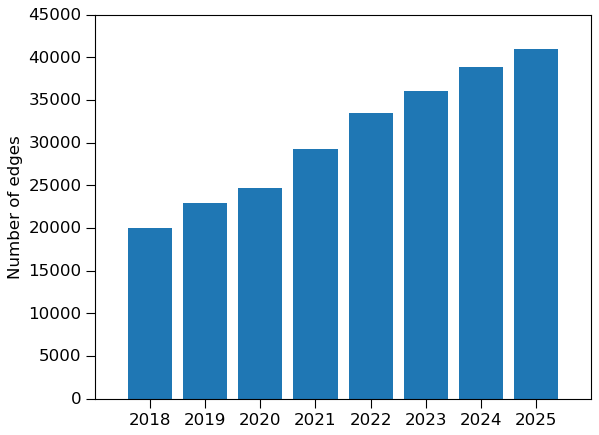

In [5]:
plt.bar([0, 1, 2, 3, 4, 5, 6, 7], [data_oct_2018.shape[0], data_oct_2019.shape[0], data_oct_2020.shape[0], data_oct_2021.shape[0], data_oct_2022.shape[0], data_oct_2023.shape[0], data_oct_2024.shape[0], data_oct_2025.shape[0]], color='#1f77b4')
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7], ['2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'])
plt.ylabel('Number of edges')


## Consider only SIGNOR_ID

In [6]:
oct_2018_ids = data_oct_2018.SIGNOR_ID
oct_2019_ids = data_oct_2019.SIGNOR_ID
oct_2020_ids = data_oct_2020.SIGNOR_ID
oct_2021_ids = data_oct_2021.SIGNOR_ID
oct_2022_ids = data_oct_2022.SIGNOR_ID
oct_2023_ids = data_oct_2023.SIGNOR_ID
oct_2024_ids = data_oct_2024.SIGNOR_ID
oct_2025_ids = data_oct_2025.SIGNOR_ID

# Set of unique edges
oct_2018_ids_set = set(oct_2018_ids)
oct_2019_ids_set = set(oct_2019_ids)
oct_2020_ids_set = set(oct_2020_ids)
oct_2021_ids_set = set(oct_2021_ids)
oct_2022_ids_set = set(oct_2022_ids)
oct_2023_ids_set = set(oct_2023_ids)
oct_2024_ids_set = set(oct_2024_ids)
oct_2025_ids_set = set(oct_2025_ids)

In [7]:
removed_ids_2018_2019 = oct_2018_ids_set - oct_2018_ids_set.intersection(oct_2019_ids_set)
removed_ids_2019_2020 = oct_2019_ids_set - oct_2019_ids_set.intersection(oct_2020_ids_set)
removed_ids_2020_2021 = oct_2020_ids_set - oct_2020_ids_set.intersection(oct_2021_ids_set)
removed_ids_2021_2022 = oct_2021_ids_set - oct_2021_ids_set.intersection(oct_2022_ids_set)
removed_ids_2022_2023 = oct_2022_ids_set - oct_2022_ids_set.intersection(oct_2023_ids_set)
removed_ids_2023_2024 = oct_2023_ids_set - oct_2023_ids_set.intersection(oct_2024_ids_set)
removed_ids_2024_2025 = oct_2024_ids_set - oct_2024_ids_set.intersection(oct_2025_ids_set)

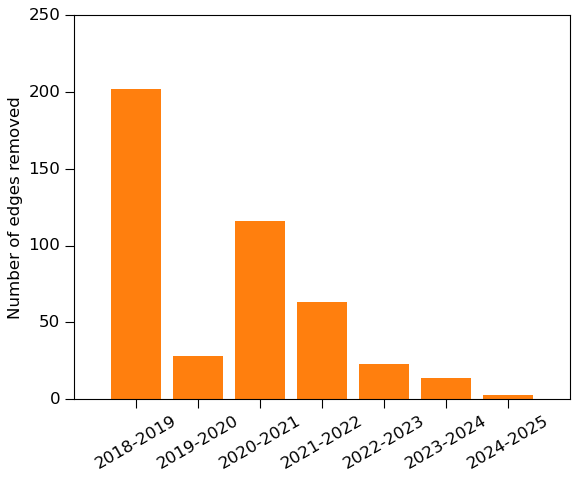

In [8]:
plt.bar([0, 1, 2, 3, 4, 5, 6], [len(removed_ids_2018_2019), len(removed_ids_2019_2020), len(removed_ids_2020_2021), len(removed_ids_2021_2022), len(removed_ids_2022_2023), len(removed_ids_2023_2024), len(removed_ids_2024_2025)], color='#ff7f0e')
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025'])
# Rotate x-axis labels
plt.xticks(rotation=30)
plt.ylabel('Number of edges removed')
plt.show()

## Consider also the source and target name

In [9]:
def find_reassigned_edges(removed_ids: set, old_data: pd.DataFrame, new_data: pd.DataFrame, consider_interaction: bool = True) -> List[Dict[str, Any]]:
    """
    Validate if edges marked as removed actually still exist in new data with different IDs.
    
    Args:
        removed_ids: Set of SIGNOR_IDs that appear to be removed
        old_data: DataFrame containing the old release data
        new_data: DataFrame containing the new release data
        consider_interaction: Whether to match on interaction type as well
    
    Returns:
        List of edges that still exist in new data despite being marked as removed
    """
    reassigned_edges = []
    
    for old_signor_id in removed_ids:
        # Step 1: Find the edge details in the old data using SIGNOR_ID
        if not pd.isna(old_signor_id):
            old_edge_row = old_data[old_data['SIGNOR_ID'] == old_signor_id]
        else:
            old_edge_row = old_data[old_data['SIGNOR_ID'].isna()]
        
        # Extract edge components from old data
        source_entity = old_edge_row['ENTITYA'].iloc[0]
        target_entity = old_edge_row['ENTITYB'].iloc[0]
        effect_type = old_edge_row['EFFECT'].iloc[0]

        # Step 2: Check if the same edge exists in the new data
        if consider_interaction:
            matching_edges = new_data[
                (new_data['ENTITYA'] == source_entity) & 
                (new_data['ENTITYB'] == target_entity) & 
                (new_data['EFFECT'] == effect_type)
            ]
            
            if not matching_edges.empty:
                reassigned_edges.append({
                    'old_signor_id': old_signor_id,
                    'source_entity': source_entity,
                    'target_entity': target_entity,
                    'effect_type': effect_type,
                    'new_signor_id': matching_edges['SIGNOR_ID'].iloc[0]
                })
        else:
            matching_edges = new_data[
                (new_data['ENTITYA'] == source_entity) & 
                (new_data['ENTITYB'] == target_entity)
            ]
            
            if not matching_edges.empty:
                reassigned_edges.append({
                    'old_signor_id': old_signor_id,
                    'source_entity': source_entity,
                    'target_entity': target_entity,
                    'new_signor_id': matching_edges['SIGNOR_ID'].iloc[0]
                })
    
    return reassigned_edges

In [10]:
reassigned_edges = find_reassigned_edges(removed_ids_2018_2019, data_oct_2018, data_oct_2019, consider_interaction=False)
# There are plenty edges with different SIGNOR_ID from different years.
print(len(reassigned_edges))
print(reassigned_edges[:5])

176
[{'old_signor_id': 'SIGNOR-252936', 'source_entity': 'FOXO', 'target_entity': 'FBXO32', 'new_signor_id': 'SIGNOR-252926'}, {'old_signor_id': 'SIGNOR-251728', 'source_entity': 'NFATC1', 'target_entity': 'IL4', 'new_signor_id': 'SIGNOR-254498'}, {'old_signor_id': 'SIGNOR-229754', 'source_entity': 'TNF', 'target_entity': 'TNFRSF1A', 'new_signor_id': 'SIGNOR-226676'}, {'old_signor_id': 'SIGNOR-254899', 'source_entity': 'GATOR1', 'target_entity': 'RRAGB', 'new_signor_id': 'SIGNOR-253563'}, {'old_signor_id': 'SIGNOR-109019', 'source_entity': 'FBXW7', 'target_entity': 'NOTCH1', 'new_signor_id': 'SIGNOR-130706'}]


In [11]:
removed_ids_list = [removed_ids_2018_2019, removed_ids_2019_2020, removed_ids_2020_2021, removed_ids_2021_2022, removed_ids_2022_2023, removed_ids_2023_2024, removed_ids_2024_2025]
old_data_list = [data_oct_2018, data_oct_2019, data_oct_2020, data_oct_2021, data_oct_2022, data_oct_2023, data_oct_2024]
new_data_list = [data_oct_2019, data_oct_2020, data_oct_2021, data_oct_2022, data_oct_2023, data_oct_2024, data_oct_2025]

removed_edges_list = []
for i, removed_ids in enumerate(removed_ids_list):
    reassigned_edges = find_reassigned_edges(removed_ids, old_data_list[i], new_data_list[i], consider_interaction=False)
    # Delete the edges in the removed_ids that is in the reassigned_edges.
    for edge in reassigned_edges:
        if edge['old_signor_id'] in removed_ids:
            removed_ids.remove(edge['old_signor_id'])
    removed_edges_list.append(removed_ids)

In [12]:
removed_nums = [len(removed_ids) for removed_ids in removed_edges_list]
print('total removed edges:', sum(removed_nums))

total removed edges: 141


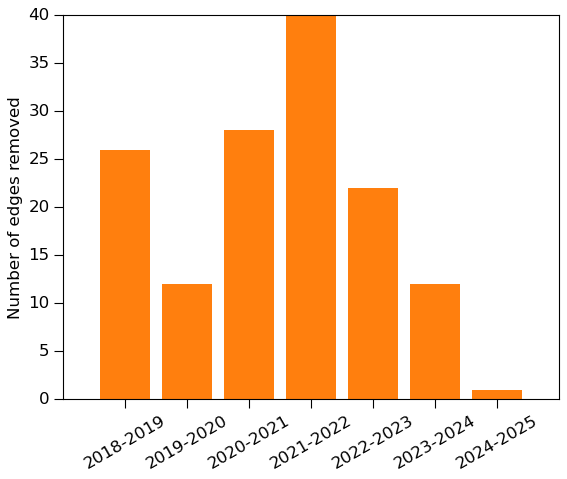

In [13]:
plt.bar([0, 1, 2, 3, 4, 5, 6], [len(removed_edges_list[0]), len(removed_edges_list[1]), len(removed_edges_list[2]), len(removed_edges_list[3]), len(removed_edges_list[4]), len(removed_edges_list[5]), len(removed_edges_list[6])], color='#ff7f0e')
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025'])
# Rotate x-axis labels
plt.xticks(rotation=30)
plt.ylabel('Number of edges removed')
plt.show()

## Remove the edges that one of the node is completely removed from the 2025 graph.

In [14]:
removed_edges_with_node_exist_in_2025_list = [s.copy() for s in removed_edges_list]
for i, removed_edges in enumerate(removed_edges_list):
    for removed_id in list(removed_edges):
        old_edge_row = old_data_list[i][old_data_list[i]['SIGNOR_ID'] == removed_id]
        source_entity = old_edge_row['ENTITYA'].iloc[0]
        target_entity = old_edge_row['ENTITYB'].iloc[0]
        if (source_entity not in set(data_oct_2025['ENTITYA']).union(set(data_oct_2025['ENTITYB']))) or (target_entity not in set(data_oct_2025['ENTITYA']).union(set(data_oct_2025['ENTITYB']))):
            print(f"source: {source_entity}, targes: {target_entity}")
            removed_edges_with_node_exist_in_2025_list[i].remove(removed_id)

source: CBFβ-MYH11, targes: TP53
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: DHH, targes: PTCH2
source: RUNX2, targes: Osteoblast Differentiation
source: STAT3, targes: STAT1A/STAT3/STAT5A/STAT5B
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: STAT1, targes: STAT1A/STAT3/STAT5A/STAT5B
source: STAT5B, targes: STAT1A/STAT3/STAT5A/STAT5B
source: STAT5A, targes: STAT1A/STAT3/STAT5A/STAT5B
source: dinoprost, targes: MYOD1
source: DHH, targes: PTCH1
source: cAMP, targes: PRKACA
source: STAT1A/STAT3/STAT5A/STAT5B, targes: Proliferation
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: HHIP, targes: DHH
source: CTNNB1, targes: HIST1H3A
source: BCL2, targes: BAK/BAX
source: BID, targes: BAK/BAX
source: BCL2L1, targes: BAK/BAX
source: BAK/BAX, targes: Apoptosis
source: BAK1, targes: BAK/BAX
source: BCL2L11, targes: BAK/BAX
source: BAK/BAX, targes: DIABLO
source: BCR/ABL fusion, targe

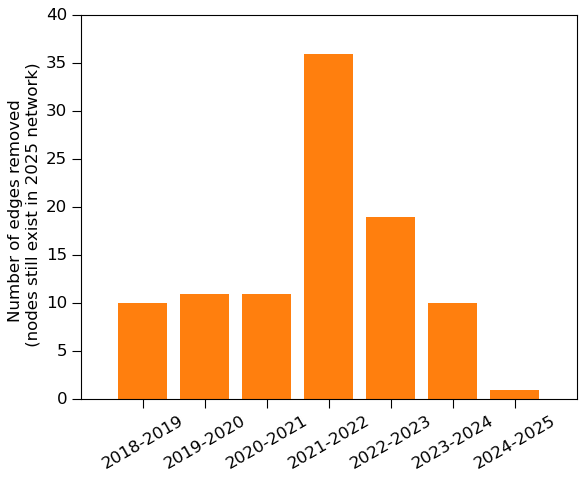

In [15]:
plt.bar([0, 1, 2, 3, 4, 5, 6], [len(removed_edges_with_node_exist_in_2025_list[0]), len(removed_edges_with_node_exist_in_2025_list[1]), len(removed_edges_with_node_exist_in_2025_list[2]), len(removed_edges_with_node_exist_in_2025_list[3]), len(removed_edges_with_node_exist_in_2025_list[4]), len(removed_edges_with_node_exist_in_2025_list[5]), len(removed_edges_with_node_exist_in_2025_list[6])], color='#ff7f0e')
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025'])
# Rotate x-axis labels
plt.xticks(rotation=30)
plt.ylabel('Number of edges removed \n (nodes still exist in 2025 network)')
plt.show()

In [16]:
# Check if there is any removed edges that has been reassigned in the latest 2025 data
add_back_ids = []
for i, removed_edges in enumerate(removed_edges_with_node_exist_in_2025_list):
    reassigned_edges = find_reassigned_edges(removed_edges, old_data_list[i], data_oct_2025, consider_interaction=False)
    print(f"From {i}th removed edges, found {len(reassigned_edges)} reassigned edges in 2025 data.")
    if len(reassigned_edges) > 0:
        print(reassigned_edges)
        for edge in reassigned_edges:
            add_back_ids.append(edge['old_signor_id'])

From 0th removed edges, found 0 reassigned edges in 2025 data.
From 1th removed edges, found 0 reassigned edges in 2025 data.
From 2th removed edges, found 1 reassigned edges in 2025 data.
[{'old_signor_id': 'SIGNOR-170134', 'source_entity': 'TRPM7', 'target_entity': 'EEF2K', 'new_signor_id': 'SIGNOR-277923'}]
From 3th removed edges, found 0 reassigned edges in 2025 data.
From 4th removed edges, found 0 reassigned edges in 2025 data.
From 5th removed edges, found 0 reassigned edges in 2025 data.
From 6th removed edges, found 0 reassigned edges in 2025 data.


## Save the removed edges as a csv table

In [17]:
file_names = ['Oct2018_release', 'Oct2019_release', 'Oct2020_release', 'Oct2021_release', 'Oct2022_release', 'Oct2023_release', 'Oct2024_release', 'Oct2025_release']
data_list = [data_oct_2018, data_oct_2019, data_oct_2020, data_oct_2021, data_oct_2022, data_oct_2023, data_oct_2024, data_oct_2025]

all_removed_edges_data = []

for i, removed_edges in enumerate(removed_edges_with_node_exist_in_2025_list):
    for removed_id in removed_edges:
        old_edge_row = old_data_list[i][old_data_list[i]['SIGNOR_ID'] == removed_id]
        if not old_edge_row.empty and removed_id not in add_back_ids:
            edge_dict = old_edge_row.iloc[0].to_dict()
            edge_dict['source_release'] = file_names[i]  # Add source release column
            all_removed_edges_data.append(edge_dict)

# Create one big DataFrame with all removed edges
all_removed_edges_df = pd.DataFrame(all_removed_edges_data)

# Save to single CSV file
all_removed_edges_df.to_csv('all_removed_edges_with_sources.csv', index=False)

print(f"Saved {len(all_removed_edges_df)} removed edges to 'all_removed_edges_with_sources.csv'")

Saved 97 removed edges to 'all_removed_edges_with_sources.csv'


## Check protein-protein interaction only

In [18]:
protein_removed_edges_df = all_removed_edges_df[(all_removed_edges_df['TYPEA'] == 'protein') & (all_removed_edges_df['TYPEB'] == 'protein')]
print(f"Number of protein-protein removed edges: {len(protein_removed_edges_df)}")

Number of protein-protein removed edges: 30


In [19]:
# Find duplicate edges based on ENTITYA, ENTITYB, and EFFECT columns
duplicate_edges = protein_removed_edges_df[protein_removed_edges_df.duplicated(subset=['ENTITYA', 'ENTITYB', 'EFFECT'], keep=False)]
print(f"Number of duplicate removed edges: {len(duplicate_edges)}")


Number of duplicate removed edges: 8


In [20]:
duplicate_edges

,ENTITYA,TYPEA,IDA,DATABASEA,ENTITYB,TYPEB,IDB,DATABASEB,EFFECT,MECHANISM,...,MODASEQ,MODIFICATIONB,MODBSEQ,PMID,DIRECT,NOTES,ANNOTATOR,SENTENCE,SIGNOR_ID,source_release
11,GNAO1,protein,P09471,UNIPROT,ADCY1,protein,Q08828,UNIPROT,down-regulates,binding,...,NaN,NaN,NaN,17419683,t,NaN,gcesareni,Members of the gi family are linked with reduc...,SIGNOR-153467,Oct2019_release
13,GNAT1,protein,P11488,UNIPROT,ADCY1,protein,Q08828,UNIPROT,down-regulates,binding,...,NaN,NaN,NaN,17419683,t,NaN,gcesareni,Members of the gi family are linked with reduc...,SIGNOR-153923,Oct2019_release
17,GNAT1,protein,P11488,UNIPROT,ADCY1,protein,Q08828,UNIPROT,down-regulates,binding,...,NaN,NaN,NaN,8327893,t,NaN,gcesareni,Members of the gi family are linked with reduc...,SIGNOR-38137,Oct2019_release
18,GNAO1,protein,P09471,UNIPROT,ADCY1,protein,Q08828,UNIPROT,down-regulates,binding,...,NaN,NaN,NaN,8327893,t,NaN,gcesareni,Members of the gi family are linked with reduc...,SIGNOR-38079,Oct2019_release
24,AKT1,protein,P31749,UNIPROT,PPP1CA,protein,P62136,UNIPROT,down-regulates,phosphorylation,...,NaN,NaN,NaN,12202491,t,NaN,gcesareni,Ir-induced pp1 activation in the nucleus may b...,SIGNOR-92257,Oct2020_release
26,AKT1,protein,P31749,UNIPROT,PPP1CA,protein,P62136,UNIPROT,down-regulates,phosphorylation,...,NaN,NaN,NaN,17202132,t,NaN,gcesareni,Ir-induced pp1 activation in the nucleus may b...,SIGNOR-252498,Oct2020_release
67,AURKA,protein,O14965,UNIPROT,AR,protein,P10275,UNIPROT,up-regulates activity,phosphorylation,...,NaN,NaN,NaN,20713353,t,NaN,miannu,Phosphorylation and activation of androgen rec...,SIGNOR-259827,Oct2022_release
71,AURKA,protein,O14965,UNIPROT,AR,protein,P10275,UNIPROT,up-regulates activity,phosphorylation,...,NaN,NaN,NaN,20713353,t,NaN,miannu,Phosphorylation and activation of androgen rec...,SIGNOR-259828,Oct2022_release


# 2. True edges

Workflow:
1. Start with the latest version of the data (data_oct_2025).
1. Consider only the protein-protein interactions for now.
1. Filter the data by considering positive edges containing nodes from the negative edges. The reason is that those nodes might be more carefully human-curated, thus the remaining positive edges are more reliable.
1. Access the Omnipath database and extract the reference number for each of the interaction.
1. Remove the duplicate.
1. When it comes to the self-loop, consider only the higher reference number one.
1. When it comes to edges from the same source node, consider only the highest reference number one.

## True edges with nodes from False edges

In [21]:
# Only consider the protein-protein interactions
data_oct_2025_ppi = data_oct_2025[(data_oct_2025['TYPEA'] == 'protein') & (data_oct_2025['TYPEB'] == 'protein')]
print(f"Number of protein-protein interactions in Signor Oct 2025 data: {data_oct_2025_ppi.shape[0]}")

Number of protein-protein interactions in Signor Oct 2025 data: 26127


In [22]:
# Get candidate source nodes from removed edges. 
candidate_source_nodes = set()
for row in all_removed_edges_df.itertuples():
    if row.TYPEA != 'protein' or row.TYPEB != 'protein':
        continue
    source_entity = row.ENTITYA
    target_entity = row.ENTITYB
    candidate_source_nodes.add(source_entity)
    candidate_source_nodes.add(target_entity)

In [23]:
index_list = []
for node in list(candidate_source_nodes):
    indeces = data_oct_2025_ppi[(data_oct_2025_ppi['ENTITYA'] == node) | (data_oct_2025_ppi['ENTITYB'] == node)]
    index_list.extend(indeces.index.tolist())

In [24]:
data_oct_2025_ppi_subset = data_oct_2025_ppi.loc[index_list].drop_duplicates()
print(f"Number of candidate positive edges: {data_oct_2025_ppi_subset.shape[0]}")

Number of candidate positive edges: 3887


## Ominipath refs

In [69]:
# all_interactions[(all_interactions['source_genesymbol'] == 'BMI1') &
#         (all_interactions['target_genesymbol'] == 'CDKN2A')]

,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,curation_effort,references,sources,type,n_sources,n_primary_sources,n_references,references_stripped
1987,P35226,Q8N726,BMI1,CDKN2A,True,True,True,True,False,True,11,ACSN:11283613;ACSN:15640618;ACSN:17936558;ACSN...,ACSN;SPIKE;SPIKE_LC;Wang,post_translational,4,3,10,11283613;15640618;17936558;19404261;20818389;2...
1988,P35226,P42771,BMI1,CDKN2A,True,True,True,True,False,True,11,ACSN:11283613;ACSN:15640618;ACSN:17936558;ACSN...,ACSN;SPIKE;SPIKE_LC;Wang,post_translational,4,3,10,11283613;15640618;17936558;19404261;20818389;2...
269820,P35226,Q8N726,BMI1,CDKN2A,True,False,True,True,False,True,1,SIGNOR:24392140,SIGNOR,transcriptional,1,1,1,24392140
269821,P35226,P42771,BMI1,CDKN2A,True,False,True,True,False,True,1,SIGNOR:24392140,SIGNOR,transcriptional,1,1,1,24392140


In [65]:
all_interactions = AllInteractions.get(
    genesymbols=1,
    fields=['sources', 'references']
)

# Check OmniPath references for all positive edges
results_list = []
for idx, row in tqdm(data_oct_2025_ppi_subset.iterrows(), total=len(data_oct_2025_ppi_subset)):
    source = row['ENTITYA']
    target = row['ENTITYB']
    effect = row['EFFECT']  # Get the interaction type
    pmid = row['PMID']
    
    # Query OmniPath for this edge
    matches = all_interactions[
        (all_interactions['source_genesymbol'] == source) &
        (all_interactions['target_genesymbol'] == target) &
        (all_interactions['references_stripped'].str.contains(pmid, na=False))
    ]

    # Store results
    result = {
        'source': source,
        'target': target,
        'effect': effect,  # Add interaction type to results
        'pmid': pmid,
        'found_in_omnipath': len(matches) > 0,
        'n_references': matches['n_references'].iloc[0] if len(matches) > 0 else 0,
        'n_sources': matches['n_sources'].iloc[0] if len(matches) > 0 else 0,
    }
    results_list.append(result)

# Create summary dataframe
omnipath_summary = pd.DataFrame(results_list)
print(f"\nTotal edges checked: {len(omnipath_summary)}")
print(f"Found in OmniPath: {omnipath_summary['found_in_omnipath'].sum()}")
print(f"NOT found in OmniPath: {(~omnipath_summary['found_in_omnipath']).sum()}")
print(f"\nAverage references (for found edges): {omnipath_summary[omnipath_summary['found_in_omnipath']]['n_references'].mean():.1f}")
print(f"Median references (for found edges): {omnipath_summary[omnipath_summary['found_in_omnipath']]['n_references'].median():.1f}")

100%|██████████| 3887/3887 [04:39<00:00, 13.93it/s]


Total edges checked: 3887
Found in OmniPath: 3649
NOT found in OmniPath: 238

Average references (for found edges): 12.4
Median references (for found edges): 3.0


In [66]:
# Find interactions with most citations (remove duplicates)
# First, remove duplicate source-target pairs by keeping the one with most references
omnipath_summary_unique = omnipath_summary[omnipath_summary['n_references'] > 0].sort_values('n_references', ascending=False)
omnipath_summary_unique = omnipath_summary_unique.drop_duplicates(subset=['source', 'target', 'effect'], keep='first')

print("Top 50 UNIQUE interactions by number of references in OmniPath:")
print("="*70)
count = 0
for idx, row in omnipath_summary_unique.iterrows():
    if count >= 50:
        break
    print(f"{row['source']:10s} {row['target']:10s}  |  {int(row['n_references']):3d} refs  |  {int(row['n_sources']):2d} sources")
    count += 1
    
print("\n" + "="*70)
print(f"\nInteraction with MOST citatißons:")
top_edge = omnipath_summary_unique.iloc[0]
print(f"  {top_edge['source']} -> {top_edge['target']}")
print(f"  References: {int(top_edge['n_references'])}")
print(f"  Sources: {int(top_edge['n_sources'])}")
print(f"\nTotal unique interactions with references: {len(omnipath_summary_unique)}")

Top 50 UNIQUE interactions by number of references in OmniPath:
RET        MAPK3       |  558 refs  |  13 sources
ATM        TP53        |  511 refs  |  35 sources
MDM2       TP53        |  466 refs  |  17 sources
TP53       CDKN1A      |  380 refs  |  24 sources
PRKDC      AKT1        |  329 refs  |  17 sources
ATR        CHEK1       |  234 refs  |  32 sources
TP53       MDM2        |  200 refs  |  22 sources
MAPK8      JUN         |  153 refs  |  45 sources
CDK2       CDKN1B      |  133 refs  |  30 sources
CHUK       NFKBIA      |  124 refs  |  33 sources
CHEK2      TP53        |  115 refs  |  31 sources
CHEK2      TP53        |  115 refs  |  31 sources
MAP2K1     MAPK1       |  110 refs  |  38 sources
DYRK2      TP53        |  110 refs  |  19 sources
DYRK2      TP53        |  110 refs  |  19 sources
ATR        TP53        |  106 refs  |  27 sources
CDK2       CCNA2       |   99 refs  |  23 sources
AR         KLK3        |   99 refs  |  21 sources
AKT1       BAD         |   96 refs  

In [74]:
# Create true_edges_df as a copy of data_oct_2025_ppi_subset and add Omnipath reference counts
true_edges_df = data_oct_2025_ppi_subset.copy()

# Add the omnipath reference count from the results_list we just created
true_edges_df['omnipath_n_references'] = [result['n_references'] for result in results_list]

In [107]:
# Iterate through SIGNOR edges that have 0 reference matches in OmniPath
for idx, row in true_edges_df[true_edges_df['omnipath_n_references'] == 0].iterrows():
    source = row['ENTITYA']
    target = row['ENTITYB']
    effect = row['EFFECT']
    
    # Transcriptional regulation
    if effect in ['up-regulates quantity by expression',
                  'up-regulates quantity',
                  'down-regulates quantity by repression']:
        regulation_type = 'transcriptional'
        consensus_stimulation = 'up-regulates' in effect
        consensus_inhibition = 'down-regulates' in effect
        
        matches = all_interactions[
            (all_interactions['source_genesymbol'] == source) &
            (all_interactions['target_genesymbol'] == target) &
            (all_interactions['type'] == regulation_type) &
            (all_interactions['consensus_stimulation'] == consensus_stimulation) &
            (all_interactions['consensus_inhibition'] == consensus_inhibition)
        ]
    
    # Post-translational regulation
    elif effect in ['up-regulates activity',
                    'up-regulates quantity by stabilization',
                    'down-regulates',
                    'down-regulates activity',
                    'down-regulates quantity',
                    'down-regulates quantity by destabilization']:
        regulation_type = 'post_translational'
        consensus_stimulation = 'up-regulates' in effect
        consensus_inhibition = 'down-regulates' in effect
        
        matches = all_interactions[
            (all_interactions['source_genesymbol'] == source) &
            (all_interactions['target_genesymbol'] == target) &
            (all_interactions['type'] == regulation_type) &
            (all_interactions['consensus_stimulation'] == consensus_stimulation) &
            (all_interactions['consensus_inhibition'] == consensus_inhibition)
        ]
    
    # Generic up/down-regulates - search both regulation types
    elif effect in ['up-regulates', 'down-regulates']:
        matches = all_interactions[
            (all_interactions['source_genesymbol'] == source) &
            (all_interactions['target_genesymbol'] == target) &
            (all_interactions['consensus_stimulation'] == ('up' in effect)) &
            (all_interactions['consensus_inhibition'] == ('down' in effect))
        ]
    
    # Unknown effect - match by genes only
    elif effect == 'unknown':
        matches = all_interactions[
            (all_interactions['source_genesymbol'] == source) &
            (all_interactions['target_genesymbol'] == target)
        ]
    
    # Unhandled effect type
    else:
        continue
    
    # Update reference count if matches found
    if len(matches) > 0:
        n_refs = matches['n_references'].iloc[0]
        print(f"source: {source}, target: {target}, effect: {effect}, n_references: {n_refs}")
        true_edges_df.loc[idx, 'omnipath_n_references'] = n_refs

source: INS, target: PIK3CG, effect: up-regulates, n_references: None
source: CHRM2, target: GNAO1, effect: up-regulates, n_references: 5
source: FGF2, target: MAPK1, effect: up-regulates, n_references: 2
source: FGF2, target: MAPK3, effect: up-regulates, n_references: 3
source: FN1, target: MAPK3, effect: up-regulates, n_references: None
source: MAP4K1, target: MAPK8, effect: up-regulates, n_references: None
source: MAPK8, target: BAX, effect: up-regulates, n_references: 3
source: IL3RA, target: STAT5A, effect: up-regulates, n_references: None
source: PIK3CA, target: AKT2, effect: up-regulates, n_references: 1
source: INS, target: AKT1, effect: up-regulates, n_references: 9
source: TNF, target: AKT1, effect: up-regulates, n_references: 1
source: AKT1, target: MEF2D, effect: up-regulates, n_references: None


## Remove duplicate

In [111]:
true_edges_df.drop_duplicates(subset=['ENTITYA', 'ENTITYB', 'EFFECT'], keep='first', inplace=True)
print(f"Number of unique true edges: {true_edges_df.shape[0]}")

Number of unique true edges: 2699


2699